In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import re
import glob
import pickle
from tqdm import tqdm
import powerlaw
import matplotlib as mpl
from datetime import datetime, timedelta
from tqdm import tqdm

data_directory = os.getcwd()[:-4] + 'data/sentiment_timeline/'
figure_directory = os.getcwd()[:-4] + 'figures/'

text_font = 18
latex_preamble = r"\usepackage{times} \usepackage{amsmath} \usepackage{amssymb}"
mpl.rcParams.update({
                    'text.usetex': True,
                    'font.size': 18, 
                    'font.style': 'normal',
                    'font.family':'serif',
                    'text.latex.preamble': latex_preamble,
                    'font.serif': ['Times']})

In [3]:
channel_names = ['ABC', 'CBS', 'CNN', 'FOX', 'Newsmax', 'OAN']

In [4]:
with open(data_directory+'dates.json', 'rb') as fp:
    dates = pickle.load(fp)


def dayIndex(row):    
    dayIndex = dates[row['year']][row['month']][row['day']]
    return dayIndex

In [66]:
breonna_taylor = dates[2020][9][24]
election_day = dates[2020][11][3]
biden_wins = dates[2020][11][7]
trump_questions = dates[2020][11][14]
bidens_transition = dates[2020][11][23]
safe_harbor = dates[2020][12][8]
electoral_votes = dates[2020][12][14]
capitol_attack = dates[2021][1][6]
inauguration = dates[2021][1][20]
daunte_wright = dates[2021][4][11]
dereck_chauvin = dates[2021][4][20]

a=dates.items()

important_dates ={}
important_dates['Breonna Taylor protests']=breonna_taylor
# important_dates['Election Day']=election_day
important_dates['Biden declared projected winner']=biden_wins
# important_dates['Trump questions results']=trump_questions
important_dates['Biden\'s transition starts']=bidens_transition
important_dates['Safe harbor deadline']=safe_harbor
important_dates['Official electoral voting']=electoral_votes
important_dates['Jan 6 U.S. Capitol Attack']=capitol_attack
important_dates['Biden\'s Inauguration']=inauguration
important_dates['Daunte Wright shot by police']=daunte_wright
important_dates['Dereck Chauvin found guilty']=dereck_chauvin

In [6]:
def merge_all_dfs():

    # Initialize a list to hold all the DataFrames
    dfs = []

    # Loop through each channel name to read and append the DataFrame to the list
    for channel in tqdm(channel_names):
        df = pd.read_csv(data_directory + f'sentiments_{channel}.csv', sep=',')
        dfs.append(df)

    # Concatenate all DataFrames in the list at once
    allConvs = pd.concat(dfs, ignore_index=True, sort=False)


    allConvs.to_csv(data_directory+'allConvs.csv', index=False)


In [7]:
df = pd.read_csv(data_directory+'allConvs.csv', sep=',')

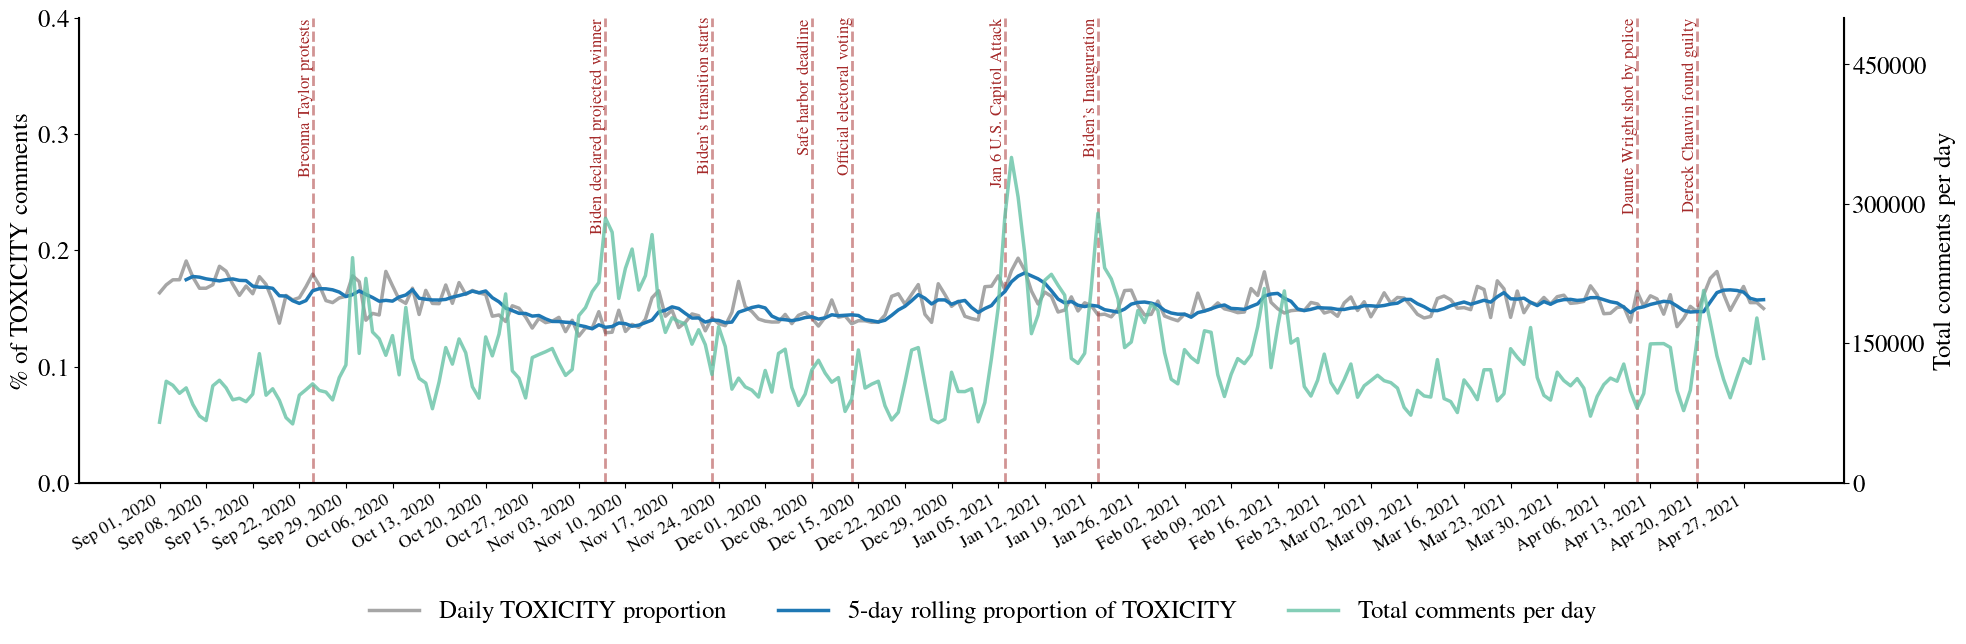

In [68]:
def timeline_plot(df, sentiment, thresh, rolling):

    fig, ax = plt.subplots(1,1, figsize=(20,6))

    
    ''' 
    collecting all the necessary data for the plot 
    '''
    z = pd.crosstab(df[sentiment+'_'+thresh], df['dayIndex'], dropna=False,normalize='columns')
    days = list(z.columns)
    senti = list(z.iloc[1])
    senti_roll = z.iloc[1].rolling(rolling).mean()
    tot_comments = df['dayIndex'].value_counts().sort_index()


    ''' 
    plot the three trend lines -- senti, senti_roll, tot_comments 
    '''
    ax.plot(days, senti, color='grey', linewidth=2.5, alpha=0.7, label=f'Daily {sentiment} proportion')
    ax.plot(days, senti_roll, color='#1f78b4', linewidth=2.5, label=f'{rolling}-day rolling proportion of {sentiment}', zorder=100)
    ax2 = ax.twinx()
    ax2.plot(tot_comments.index, tot_comments.values, color='#66c2a5',linewidth=2.5, alpha=0.8, label='Total comments per day')



    ''' plot the locations of the important events '''
    for event, day in important_dates.items():
        ax.axvline(day, color='brown', linestyle='--', alpha=0.5, linewidth=2)
        ax.text(day, 0.4, event, rotation=90, fontsize=12, ha='right', va='top', color='brown')
    


    ''' xlabel '''
    x_label = list(np.arange(1, 242, 7))
    x_time = [datetime(2020,9,1)]
    x_time +=  [x_time[0]+timedelta(int(t)-1) for t in x_label[1:]]
    x_time = [t.strftime('%b %d, %Y') for t in x_time]
    ax.set_xticks(x_label)
    ax.set_xticklabels(x_time,rotation=30, fontsize = text_font-5, ha='right')


    ''' ylabel '''
    ax.set_ylabel(rf'$\%$ of {sentiment} comments', fontsize = text_font)
    ax2.set_ylabel('Total comments per day', fontsize = text_font)
    ax.set_ylim(0.0, 0.4)
    ax2.set_ylim(0, 5e5)
    ax.yaxis.set_major_locator(plt.MaxNLocator(4))
    ax2.yaxis.set_major_locator(plt.MaxNLocator(4))
    

    ''' general axis decoration '''
    ax.spines["top"].set_visible(False)
    ax2.spines["top"].set_visible(False)
    ax.spines["right"].set_linewidth(1.5)
    ax.spines["left"].set_linewidth(1.5)
    ax.spines["bottom"].set_linewidth(1.5)


    ''' legend '''
    # Collect handles and labels for both axes
    handles1, labels1 = ax.get_legend_handles_labels()
    handles2, labels2 = ax2.get_legend_handles_labels()
    
    # Combine handles and labels
    handles = handles1 + handles2
    labels = labels1 + labels2
    
    # Create a single legend for both axes
    fig.legend(handles, labels, loc='center', bbox_to_anchor=(0.5, -0.05), fontsize=text_font, ncol=3, frameon=False)


    plt.tight_layout()
    plt.savefig(figure_directory+f'timeline_{sentiment}_{thresh}_{rolling}.png', dpi=300, format='png', bbox_inches='tight')
    plt.show()
    plt.close()
    


timeline_plot(df = df, sentiment = 'TOXICITY', thresh = '0.5', rolling = 5)